In [1]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [2]:
print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
c:\Users\Hp\Downloads\Last Year Project\Main Project'\notebooks


In [5]:
df = pd.read_csv("../data/raw/stroke/stroke_raw.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [6]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [7]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [8]:
print("Dataset Shape:")
print(df.shape)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])


Dataset Shape:
(5110, 12)

Number of Rows: 5110
Number of Columns: 12


In [9]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [10]:
# ============================================================
# CELL 8: STATISTICAL SUMMARY
# ============================================================

print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [11]:
print("Missing Values in Each Column:")
print(df.isnull().sum())


Missing Values in Each Column:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [12]:
# Handle missing values in BMI

print("Missing BMI before:", df["bmi"].isnull().sum())

median_bmi = df["bmi"].median()

df["bmi"] = df["bmi"].fillna(median_bmi)

print("BMI Median:", median_bmi)
print("Missing BMI after:", df["bmi"].isnull().sum())

Missing BMI before: 201
BMI Median: 28.1
Missing BMI after: 0


In [13]:

display(df.describe())


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.862035,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.699562,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.800000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,32.800000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [14]:
print("Missing Value Percentage:")
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)


Missing Value Percentage:
id                   0.0
gender               0.0
age                  0.0
hypertension         0.0
heart_disease        0.0
ever_married         0.0
work_type            0.0
Residence_type       0.0
avg_glucose_level    0.0
bmi                  0.0
smoking_status       0.0
stroke               0.0
dtype: float64


In [15]:
print("Number of Duplicate Rows:")
print(df.duplicated().sum())

Number of Duplicate Rows:
0


In [16]:
print("\nUnique Values in Every Column:")
for column in df.columns:
    print("\n----------------------------------")
    print("Column:", column)
    print("Unique Values:")
    print(df[column].unique())
    print("Number of Unique Values:", df[column].nunique())


Unique Values in Every Column:

----------------------------------
Column: id
Unique Values:
[ 9046 51676 31112 ... 19723 37544 44679]
Number of Unique Values: 5110

----------------------------------
Column: gender
Unique Values:
['Male' 'Female' 'Other']
Number of Unique Values: 3

----------------------------------
Column: age
Unique Values:
[6.70e+01 6.10e+01 8.00e+01 4.90e+01 7.90e+01 8.10e+01 7.40e+01 6.90e+01
 5.90e+01 7.80e+01 5.40e+01 5.00e+01 6.40e+01 7.50e+01 6.00e+01 5.70e+01
 7.10e+01 5.20e+01 8.20e+01 6.50e+01 5.80e+01 4.20e+01 4.80e+01 7.20e+01
 6.30e+01 7.60e+01 3.90e+01 7.70e+01 7.30e+01 5.60e+01 4.50e+01 7.00e+01
 6.60e+01 5.10e+01 4.30e+01 6.80e+01 4.70e+01 5.30e+01 3.80e+01 5.50e+01
 1.32e+00 4.60e+01 3.20e+01 1.40e+01 3.00e+00 8.00e+00 3.70e+01 4.00e+01
 3.50e+01 2.00e+01 4.40e+01 2.50e+01 2.70e+01 2.30e+01 1.70e+01 1.30e+01
 4.00e+00 1.60e+01 2.20e+01 3.00e+01 2.90e+01 1.10e+01 2.10e+01 1.80e+01
 3.30e+01 2.40e+01 3.40e+01 3.60e+01 6.40e-01 4.10e+01 8.80e-01 5.00

In [17]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns

print("Numerical Columns:")
print(numerical_columns.tolist())

print("\nCategorical Columns:")
print(categorical_columns.tolist())

Numerical Columns:
['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']

Categorical Columns:
['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


In [18]:
for column in df.columns:

    print("\n" + "=" * 60)
    print("COLUMN:", column)
    print("DATA TYPE:", df[column].dtype)
    print("NUMBER OF UNIQUE VALUES:", df[column].nunique())

    print("\nVALUE COUNTS:")
    print(df[column].value_counts(dropna=False))


COLUMN: id
DATA TYPE: int64
NUMBER OF UNIQUE VALUES: 5110

VALUE COUNTS:
id
44679    1
9046     1
51676    1
31112    1
60182    1
        ..
12109    1
60491    1
27419    1
10434    1
53882    1
Name: count, Length: 5110, dtype: int64

COLUMN: gender
DATA TYPE: object
NUMBER OF UNIQUE VALUES: 3

VALUE COUNTS:
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

COLUMN: age
DATA TYPE: float64
NUMBER OF UNIQUE VALUES: 104

VALUE COUNTS:
age
78.00    102
57.00     95
52.00     90
54.00     87
51.00     86
        ... 
1.40       3
0.48       3
0.16       3
0.08       2
0.40       2
Name: count, Length: 104, dtype: int64

COLUMN: hypertension
DATA TYPE: int64
NUMBER OF UNIQUE VALUES: 2

VALUE COUNTS:
hypertension
0    4612
1     498
Name: count, dtype: int64

COLUMN: heart_disease
DATA TYPE: int64
NUMBER OF UNIQUE VALUES: 2

VALUE COUNTS:
heart_disease
0    4834
1     276
Name: count, dtype: int64

COLUMN: ever_married
DATA TYPE: object
NUMBER OF UNIQUE VALUES:

In [19]:
print("Zero Values in Each Column:")
zero_counts = (df == 0).sum()

print(zero_counts)


Zero Values in Each Column:
id                      0
gender                  0
age                     0
hypertension         4612
heart_disease        4834
ever_married            0
work_type               0
Residence_type          0
avg_glucose_level       0
bmi                     0
smoking_status          0
stroke               4861
dtype: int64


In [21]:
print("Stroke Distribution:")
print(df["stroke"].value_counts())

print("Stroke Distribution Percentage:")
print(df["stroke"].value_counts(normalize=True) * 100)


Stroke Distribution:
stroke
0    4861
1     249
Name: count, dtype: int64
Stroke Distribution Percentage:
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


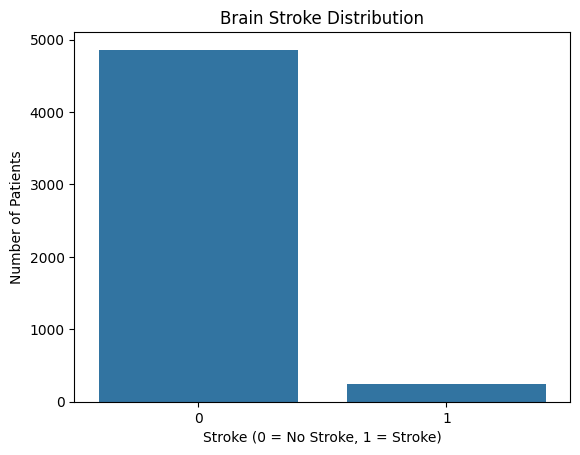

In [22]:
sns.countplot(x="stroke", data=df)

plt.title("Brain Stroke Distribution")
plt.xlabel("Stroke (0 = No Stroke, 1 = Stroke)")
plt.ylabel("Number of Patients")

plt.show()


Column: gender
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64


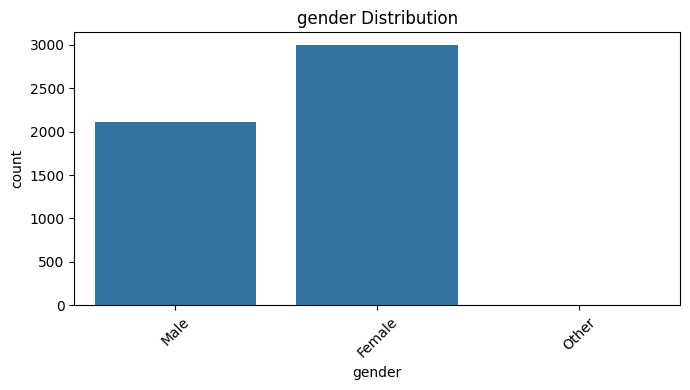


Column: ever_married
ever_married
Yes    3353
No     1757
Name: count, dtype: int64


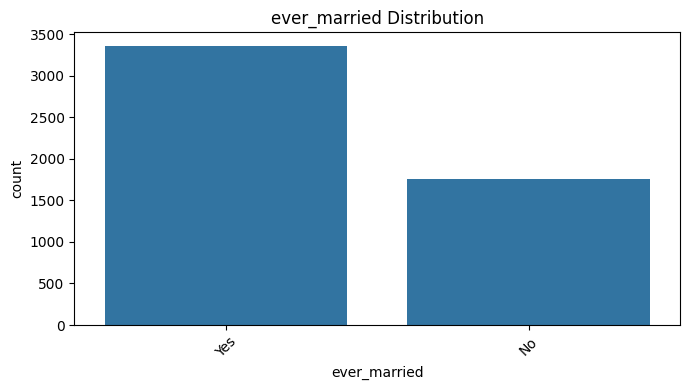


Column: work_type
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64


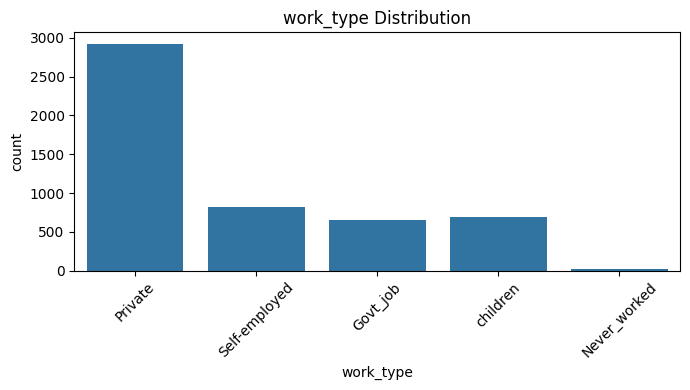


Column: Residence_type
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64


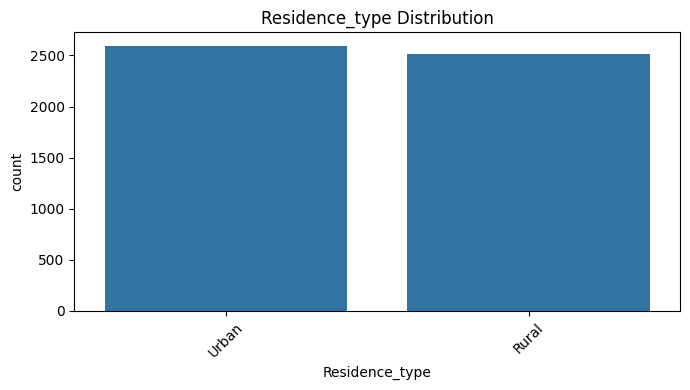


Column: smoking_status
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


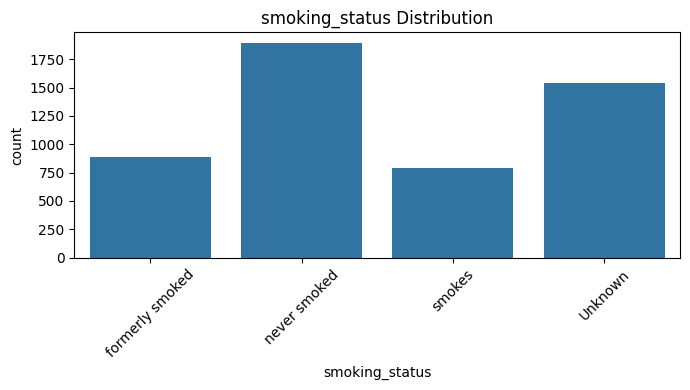

In [23]:
for column in categorical_columns:

    print("\n======================================")
    print("Column:", column)
    print(df[column].value_counts())

    plt.figure(figsize=(7, 4))

    sns.countplot(
        x=column,
        data=df
    )

    plt.title(f"{column} Distribution")
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

In [26]:
print("Final Dataset Information:")
print("Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

print("\nNumerical Columns:")
print(numerical_columns.tolist())

print("\nCategorical Columns:")
print(categorical_columns.tolist())

print("\nTarget Distribution:")
print(df["stroke"].value_counts())

print("\nEDA COMPLETED SUCCESSFULLY!")

Final Dataset Information:
Shape: (5110, 12)

Missing Values:
id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Duplicates:
0

Numerical Columns:
['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']

Categorical Columns:
['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

Target Distribution:
stroke
0    4861
1     249
Name: count, dtype: int64

EDA COMPLETED SUCCESSFULLY!
